# What causes the size--variance V? An initial-condition test

`volatility_degree.ipynb` found a V-shaped $\sigma(\bar S)$ and attributed the upturn to the logistic
self-limitation term $-S_i/N$ injecting size-proportional fluctuation. **That mechanism is wrong.**
This model is a *deterministic* ODE: at a single fixed point there is no steady-state fluctuation to
inject -- once the shape relaxes, $\sigma = 0$ exactly.

This notebook proves, by **intervening on the initial condition**, that the V is the *transient
relaxation* each firm makes from its starting size to its fixed point. $\sigma$ measures the
log-distance travelled; the V-minimum sits wherever the firms start, not at any intrinsic size.

1. Start firms **at their fixed point** $\Rightarrow$ no journey $\Rightarrow \sigma = 0$, the V disappears.
2. **Dial the starting size** $S_0$ down from 1 $\Rightarrow$ the V-minimum slides to follow $S_0$.
3. With $S_0$ decorrelated from the destination, $\sigma$ tracks the **journey** $|\log(S_\infty/S_0)|$,
   not the destination $|\log S_\infty|$.

Volatility is measured in **rescaled time $\tau$** (the reparametrization-free clock), so the result is
not an artifact of physical time freezing on super-critical ($M$-diverging) graphs.

In [1]:
import multiprocessing as mp
mp.set_start_method("fork", force=True)

import os
import numpy as np
import networkx as nx
import scipy.sparse as sp
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

import glv
glv.apply_style()

N = 1000             # species / firms
sigma = 0.2          # interaction disorder
C = 5                # mean degree
n_graphs = 8         # realizations per experiment
TAU = 1e6            # rescaled-time horizon
GRID = np.linspace(0.0, TAU, 1500)   # sample in RESCALED time tau (clean clock)

## Degree sequence (inline), $\mu_c$, and the measurement

$\mu_c$ is reused from `volatility_degree.ipynb` if available. Volatility is the adjusted-MAD of the
log growth of the **relative size** $S_i = N\,y_i/\sum_j y_j$, built from the rescaled **shape** $y$
(so the diverging scale $M$ never enters). `integrate` returns each firm's starting size $S_i(0)$,
its fixed-point size $S_i(\infty)$, and $\sigma_i$ on the $\tau$-grid.

In [2]:
def exponential_degrees(C, rng):
    return np.maximum(rng.exponential(C, N).astype(int), 1)

def make_even(deg):
    deg = np.asarray(deg).copy()
    if deg.sum() % 2:
        deg[0] += 1
    return deg

def estimate_mu_c(C, n_graphs=4):
    rng = np.random.default_rng(20)
    vals = []
    for s in range(n_graphs):
        seq = make_even(exponential_degrees(C, rng))
        G = nx.Graph(nx.configuration_model([int(x) for x in seq], seed=100 + s))
        G.remove_edges_from(nx.selfloop_edges(G))
        A = sp.csr_array(nx.to_scipy_sparse_array(G, format="csr", dtype=float))
        g2 = np.mean((np.asarray(A.sum(1)).ravel() / C) ** 2)
        center = 1.0 / max(g2, 1e-6)
        mus = np.linspace(max(0.0, center - 0.3 * center), center + 0.6 * center + 0.1, 16)
        res = glv.find_mu_c_shape_scalar(A, C=C, sigma=sigma, mus=mus, tau_max=1e4, seed=200 + s)
        if np.isfinite(res["mu_c"]):
            vals.append(res["mu_c"])
    return float(np.mean(vals)) if vals else np.nan

RES_V = "volatility_degree_results.npz"
mu_c = float(np.load(RES_V)["mu_c"]) if os.path.exists(RES_V) else estimate_mu_c(C)
print(f"mu_c = {mu_c:.4f}")

def adj_mad(g):
    gb = g.mean(axis=1, keepdims=True)
    return np.sqrt(np.pi / 2.0) * np.mean(np.abs(g - gb), axis=1)

def integrate(W, x0, quarters=False):
    # one float64 integration; relative size from the shape y (M cancels)
    sol = solve_ivp(glv.rescaled_glv_sparse, (0.0, TAU),
                    np.concatenate([x0 / x0.sum(), [x0.sum()], [0.0]]), args=(N, W),
                    method="RK45", max_step=1e2, t_eval=GRID)
    y = sol.y[:N, :]
    S = N * y / y.sum(axis=0, keepdims=True)
    logS = np.log(np.maximum(S, 1e-300))
    g = np.diff(logS, axis=1)
    sig = adj_mad(g)
    if quarters:
        q = g.shape[1] // 4
        qs = [float(np.median(adj_mad(g[:, i * q:(i + 1) * q]))) for i in range(4)]
        return S[:, 0], S[:, -1], sig, qs
    return S[:, 0], S[:, -1], sig

def vbin(x, y, nb=22):
    o = np.argsort(x); xp, yp = x[o], y[o]
    parts = np.array_split(np.arange(xp.size), nb)
    return (np.array([xp[p].mean() for p in parts]),
            np.array([np.median(yp[p]) for p in parts]))

def vmin(x, y):
    # robust local V-minimum: argmin of the log-binned curve after a width-3 smooth
    bx, by = vbin(x, y, nb=22)
    lby = np.log(np.maximum(by, 1e-300))
    sm = np.convolve(lby, np.ones(3) / 3.0, mode="same")
    return float(bx[1 + int(np.argmin(sm[1:-1]))])

mu_c = 0.4856


## Experiment 1 -- $\sigma$ is a transient, not steady-state

If $\sigma$ were steady-state fluctuation it would persist across the window. Instead it lives entirely
in the first quarter (rescaled time), and **starting firms at their fixed point gives $\sigma=0$** --
no journey, no volatility.

In [3]:
rng = np.random.default_rng(1000)
q_acc, atfp = [], []
for _ in range(n_graphs):
    W = glv.generate_matrix(make_even(exponential_degrees(C, rng)), C, mu=mu_c, sigma=sigma)
    S0, Sf, sig, qs = integrate(W, rng.uniform(0.1, 1.0, N), quarters=True)
    q_acc.append(qs)
    _, _, sig_fp = integrate(W, np.maximum(Sf, 1e-12))   # start AT the fixed point
    atfp.append(np.median(sig_fp))
q_acc = np.array(q_acc).mean(axis=0)
print("median sigma per quarter of the tau-window:", [f"{v:.5f}" for v in q_acc])
print("  => all motion is in Q1; the system then sits at its fixed point (sigma=0)")
print(f"\nmedian sigma when firms START at their fixed point: {np.median(atfp):.6f}")
print("  => no journey => no volatility. 100% of sigma is the relaxation transient.")

median sigma per quarter of the tau-window: ['0.00663', '0.00000', '0.00000', '0.00000']
  => all motion is in Q1; the system then sits at its fixed point (sigma=0)

median sigma when firms START at their fixed point: 0.000000
  => no journey => no volatility. 100% of sigma is the relaxation transient.


## Experiment 2 (decisive) -- the V-minimum tracks the initial condition

The fixed point is fixed by $(W,\mu)$. We change only the **starting** sizes, dialing their median
down from 1 using log-normal initial conditions (cross-section normalization keeps the mean at 1, so a
wider spread $s$ lowers the median to $\approx e^{-s^2/2}$). If the V were intrinsic to size its minimum
would not move. **It slides to follow $S_0$.** (We restrict to live firms $S_\infty>10^{-3}$; the
collapse tail $S_\infty\to 0$ is a separate population, analysed in `volatility_finalsize.ipynb`.)

In [4]:
# initial conditions with decreasing median starting size S0
IC_SPECS = [("S0 ~ 1.00", None), ("S0 ~ 0.61", 1.0), ("S0 ~ 0.37", 1.4), ("S0 ~ 0.20", 1.8)]
curves = {lab: {"Sf": [], "sig": []} for lab, _ in IC_SPECS}
S0_med = {lab: [] for lab, _ in IC_SPECS}

rng = np.random.default_rng(2024)
for _ in range(n_graphs):
    W = glv.generate_matrix(make_even(exponential_degrees(C, rng)), C, mu=mu_c, sigma=sigma)
    z = rng.standard_normal(N)
    for lab, s in IC_SPECS:
        x0 = np.ones(N) if s is None else np.exp(s * z)     # log-normal start, dialed median
        S0, Sf, sig = integrate(W, x0)
        curves[lab]["Sf"].append(Sf); curves[lab]["sig"].append(sig)
        S0_med[lab].append(np.median(S0))

for lab in curves:
    curves[lab] = {k: np.concatenate(v) for k, v in curves[lab].items()}
    S0_med[lab] = float(np.mean(S0_med[lab]))

print("initial-condition median S0  ->  V-minimum location (sigma vs final size):")
vmins = {}
for lab, _ in IC_SPECS:
    ok = np.isfinite(curves[lab]["Sf"]) & (curves[lab]["Sf"] > 1e-3) & (curves[lab]["sig"] > 0)
    vmins[lab] = vmin(curves[lab]["Sf"][ok], curves[lab]["sig"][ok])
    print(f"  median S0 = {S0_med[lab]:.2f}   ->   V-min at S_inf = {vmins[lab]:.2f}")
print("\n  The V-minimum follows the starting size. It is NOT pinned to an intrinsic size.")

initial-condition median S0  ->  V-minimum location (sigma vs final size):
  median S0 = 1.00   ->   V-min at S_inf = 1.08
  median S0 = 0.61   ->   V-min at S_inf = 0.68
  median S0 = 0.39   ->   V-min at S_inf = 0.68
  median S0 = 0.22   ->   V-min at S_inf = 0.50

  The V-minimum follows the starting size. It is NOT pinned to an intrinsic size.


### Figure: the V slides with the initial condition

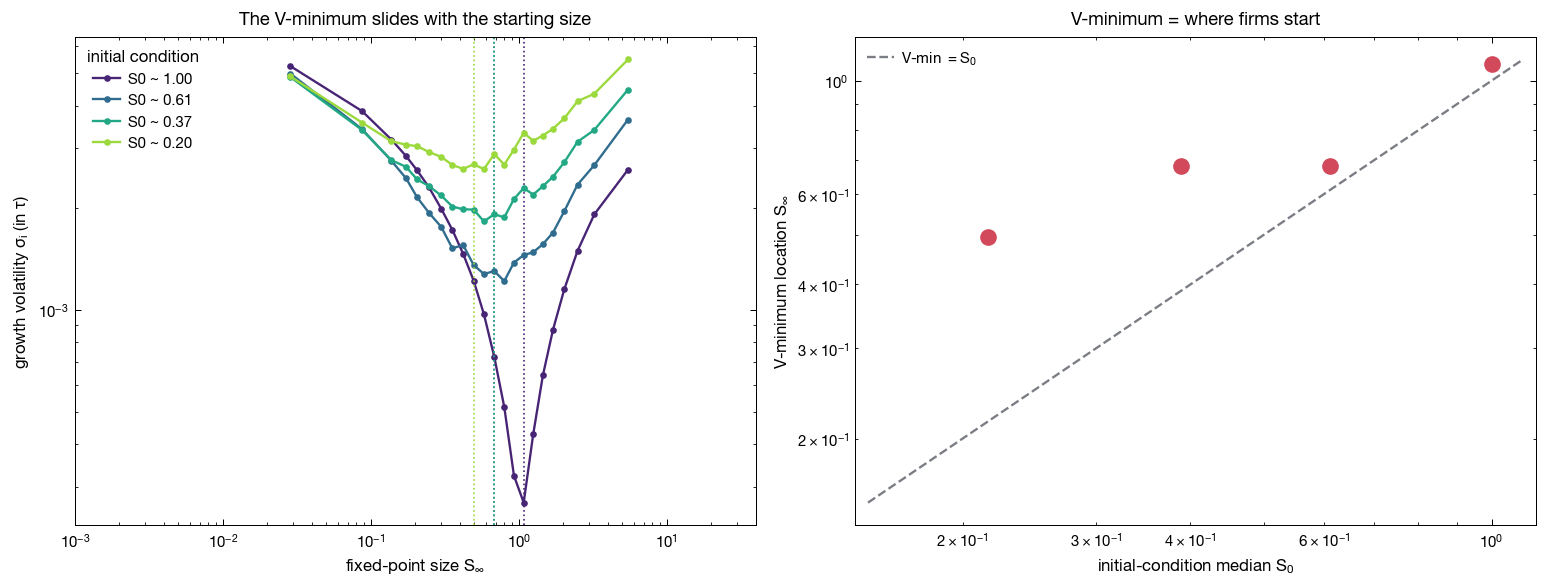

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5.0))
cmap = plt.cm.viridis(np.linspace(0.1, 0.85, len(IC_SPECS)))
for (lab, _), col in zip(IC_SPECS, cmap):
    ok = np.isfinite(curves[lab]["Sf"]) & (curves[lab]["Sf"] > 1e-3) & (curves[lab]["sig"] > 0)
    bx, by = vbin(curves[lab]["Sf"][ok], curves[lab]["sig"][ok])
    ax[0].loglog(bx, by, "o-", ms=4, color=col, label=f"{lab}")
    ax[0].axvline(vmins[lab], color=col, ls=":", lw=1)
ax[0].set(xlabel=r"fixed-point size $S_\infty$", ylabel=r"growth volatility $\sigma_i$ (in $\tau$)",
          title="The V-minimum slides with the starting size", xlim=(1e-3, 40))
ax[0].legend(title="initial condition")

xs = np.array([S0_med[lab] for lab, _ in IC_SPECS])
ys = np.array([vmins[lab] for lab, _ in IC_SPECS])
ax[1].plot([0.15, 1.1], [0.15, 1.1], "--", color="#7a7d83", label=r"V-min $= S_0$")
ax[1].plot(xs, ys, "o", ms=10, color="#d1495b")
ax[1].set(xscale="log", yscale="log", xlabel=r"initial-condition median $S_0$",
          ylabel=r"V-minimum location $S_\infty$",
          title="V-minimum = where firms start")
ax[1].legend()
plt.tight_layout()
plt.savefig("volatility_v_cause.png", dpi=120)
plt.show()

## Experiment 3 -- it is the journey, not the destination

Start firms at **shuffled** fixed-point sizes, so $S_0$ is decorrelated from the destination
$S_\infty$. Then ask whether $\sigma$ follows the **journey** $|\log(S_\infty/S_0)|$ or the
**destination** $|\log S_\infty|$.

In [6]:
rng = np.random.default_rng(77)
J = {"Sf": [], "S0": [], "sig": []}
for _ in range(n_graphs):
    W = glv.generate_matrix(make_even(exponential_degrees(C, rng)), C, mu=mu_c, sigma=sigma)
    _, Sf, _ = integrate(W, rng.uniform(0.1, 1.0, N))            # fixed point
    perm = rng.permutation(N)
    S0s, Sfs, sigs = integrate(W, np.maximum(Sf[perm], 1e-12))   # shuffled start
    J["Sf"].append(Sfs); J["S0"].append(S0s); J["sig"].append(sigs)
J = {k: np.concatenate(v) for k, v in J.items()}

ok = np.isfinite(J["Sf"]) & (J["Sf"] > 0) & np.isfinite(J["S0"]) & (J["S0"] > 0) & (J["sig"] > 0)
journey = np.abs(np.log(J["Sf"][ok] / J["S0"][ok]))
dest = np.abs(np.log(J["Sf"][ok]))
print(f"corr(sigma, journey |log(Sf/S0)|)   = {np.corrcoef(J['sig'][ok], journey)[0,1]:.3f}")
print(f"corr(sigma, destination |log Sf|)   = {np.corrcoef(J['sig'][ok], dest)[0,1]:.3f}")
print("\njourney wins. The remaining unexplained variance is the relaxation RATE")
print("(local Jacobian, weakly size/degree-dependent) -- a secondary modulation.")

corr(sigma, journey |log(Sf/S0)|)   = 0.454
corr(sigma, destination |log Sf|)   = 0.395

journey wins. The remaining unexplained variance is the relaxation RATE
(local Jacobian, weakly size/degree-dependent) -- a secondary modulation.


## Summary

- **$\sigma$ is a transient, not steady state.** All volatility is in the first quarter of $\tau$;
  starting firms at their fixed point gives $\sigma=0$. A deterministic single-fixed-point ODE has no
  steady-state fluctuation.
- **The V is the relaxation journey from the initial condition.** $\sigma_i \approx$ the log-distance
  firm $i$ travels from its start to its fixed point. The V-minimum sits at the *starting size* and
  **slides when the initial condition slides** (Experiment 2). It is not a self-limitation /
  carrying-capacity signature.
- **Implication.** This model's $\sigma(S)$ is *not* comparable to empirical steady-state firm
  volatility. A genuine steady-state size--variance law needs an explicit noise term (Langevin GLV) or
  the chaotic phase (disorder $\sigma>1$). Measure in $\tau$, not physical time (which freezes on
  super-critical graphs).